# Actividad 1: MA2003B
Author: A. Ramirez-Morales (andres.ramirez@tec.mx)

Team: Ebony Leticia Valadez Valverde, José Rafael Gutiérrez Suárez, Juan Braulio Olivares Rodríguez, Romina Nájera Fuentes

## Instrucciones:
- Complete las funciones donde vea líneas de código inconclusas
- Use comentarios para documentar de manera integral sus funciones
- Pruebe sus funciones con distintos parámetros
- Aumente las explicaciones en el Markdown y en el código
- Procure NO usar chatGPT ú otra tecnología similar, usted tiene la capacidad intelectual suficiente para resolverlo por usted mismo
- Use la documentación oficial de las librerías que se utilizan
- Se entrega un archivo PDF CANVAS como lo indique el profesor


### Verificación del uso de ambiente de conda

In [5]:
import sys
print(sys.executable)

c:\Users\romi\anaconda3\envs\mv-tec\python.exe


In [6]:
# cargar librerías básicas
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, shapiro
import pandas as pd

## 0. Introducción

### 0.1. Simulación del experimento de lanzamientos de dado
*Ejercicio:* 
- Definir el número de eventos a simular
- Definir el tipo de dado
- Simular los datos con una distribución adecuada

Para simular los datos, utilicé la función *randint* de numpy, la cual genera números aleatorios que provienen de una distribución uniforme discreta, simulando así un dado justo con una misma probabilidad de obtener cada cara.

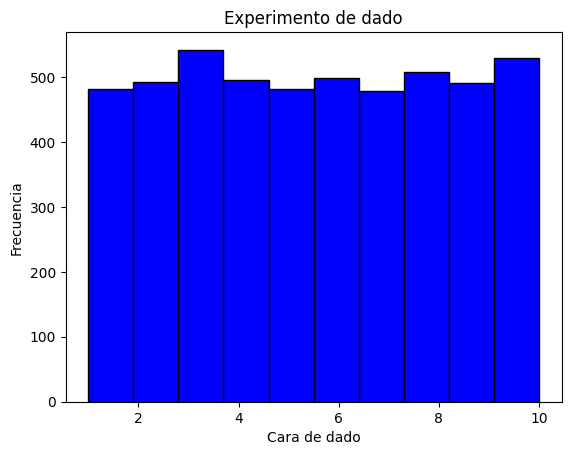

In [ ]:
events = 5000       # Cantidad de eventos a simular
face_no = 10        # Tipo de dado: Numero de caras
np.random.seed(101) # Poner semilla para reproducibilidad
data = np.random.randint(1, face_no+1, size=events) # Se generan enteros en [1, face_no+1)

# Aqui graficamos
plt.hist(data, bins=face_no, color='blue', edgecolor='black')
plt.title("Experimento de dado")
plt.xlabel("Cara de dado")
plt.ylabel("Frecuencia")
plt.show()

### 0.2. Distribuciones Gaussianas (normales)
*Ejercicio:* 
- Escriba código para generar una distribución Gaussiana. Explique los parámetros de dicha función de probabilidad.
- Repita esta actividad para la distribución de Poisson y Bernoulli


#### Distribución Gaussiana

La distribución Gaussiana, o la distribución normal, está definida por:

$f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$

Esta necesita de los siguientes parámetros:
* $\mu$: La media poblacional, la cual será el valor en donde la curva de la distribución esté centrada.
* $\sigma$: La desviación estándar. Esta representa la media de la distancia de los datos a $\mu$. Entre mayor sea este parámetro, la curva es más ancha (porque los datos están más dispersos y lejos de la media), mientras que si es más pequeño, será una curva más estrecha (ya que los datos están menos dispersos).

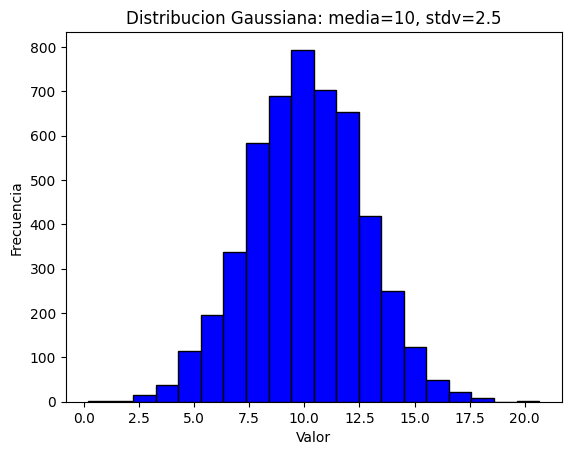

In [8]:
miu = 10                # Media
stdv = 2.5              # Desviacion estandar 
np.random.seed(101)     # Fijar semilla para reproducibilidad
data = np.random.normal(miu, stdv, size=5000) # Distribucion normal con media miu y desviacion estandar stdv
bins_no = 20            # Cantidad de barras en el histograma

# Aqui graficamos
plt.hist(data, bins=bins_no, color='blue', edgecolor='black')
plt.title(f"Distribucion Gaussiana: media={miu}, stdv={stdv}")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.show()

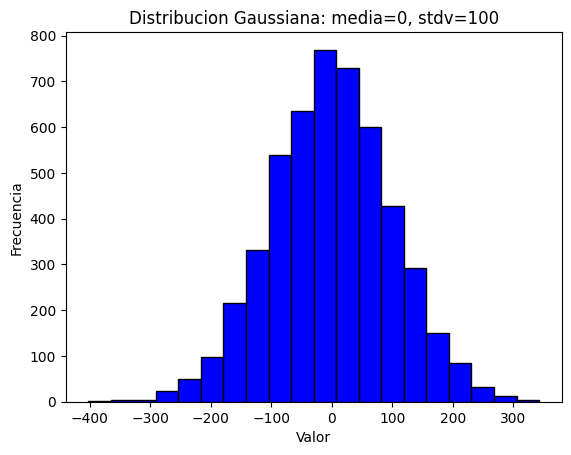

In [9]:
miu = 0                 # Media
stdv = 100              # Desviacion estandar 
np.random.seed(202)     # Fijar semilla para reproducibilidad
data = np.random.normal(miu, stdv, size=5000) # Distribucion normal con media miu y desviacion estandar stdv
bins_no = 20            # Cantidad de barras en el histograma

# Aqui graficamos
plt.hist(data, bins=bins_no, color='blue', edgecolor='black')
plt.title(f"Distribucion Gaussiana: media={miu}, stdv={stdv}")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.show()

En estos ejemplos, se ve cómo la distribución se centra en el parámetro $\mu$.

Para observar la diferencia entre las desviaciones estándar, y ver que la curva es más ancha o estrecha dependiendo de su magnitud, se pueden graficar dos distribuciones normales con una misma media y distinta desviación estándar:

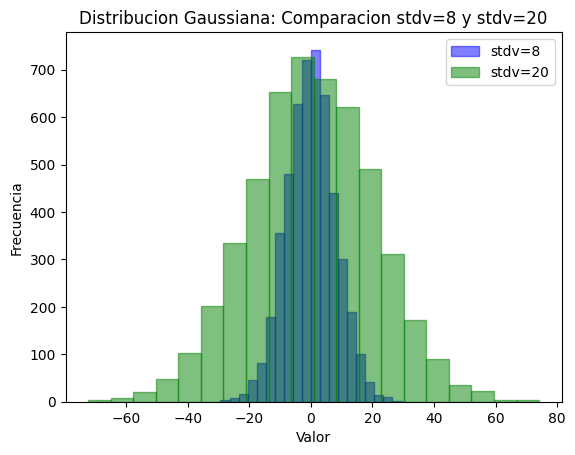

In [10]:
miu = 0
stdv1 = 8
stdv2 = 20
np.random.seed(303)
data1 = np.random.normal(miu, stdv1, size=5000)
data2 = np.random.normal(miu, stdv2, size=5000)
bins_no = 20

# Aqui graficamos
plt.hist(data1, bins=bins_no, color='blue', edgecolor='blue', alpha=0.5, label=f"stdv={stdv1}")
plt.hist(data2, bins=bins_no, color='green', edgecolor='green', alpha=0.5, label=f"stdv={stdv2}")
plt.legend()
plt.title(f"Distribucion Gaussiana: Comparacion stdv={stdv1} y stdv={stdv2}")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.show()

#### Distribución de Poisson

La distribución de Poisson está definida por:

$f(x) = \frac{e^{-\lambda} \lambda^x}{x!}$

Esta necesita del siguiente parámetro:
* $\lambda$: Representa la tasa de eventos que suceden por unidad de tiempo. Es así que una lambda pequeña implica que la cantidad de eventos que suceden en cierto tiempo es poca, por lo que la distribución se acumulará en valores pequeños, ya que es más probable que sucedan pocos eventos, mientras que conforme vamos aumentando la tasa, es más probable que suceda una mayor cantidad de eventos en el intervalo de tiempo.

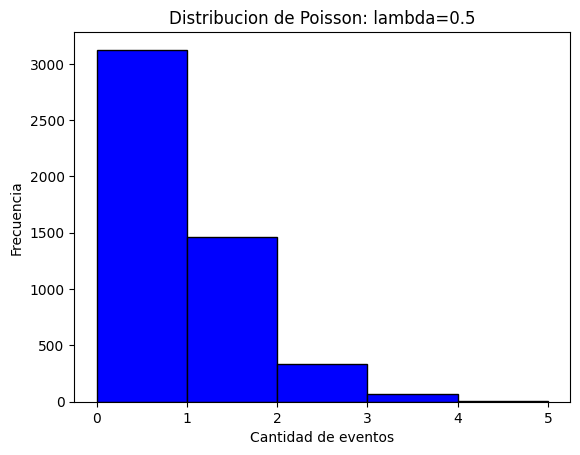

In [11]:
lambda_poi = 0.5        # Lambda
np.random.seed(404)     # Fijar semilla para reproducibilidad
data = np.random.poisson(lambda_poi, size=5000) # Distribucion Poisson con lambda lambda_poi
bins_no = 5             # Cantidad de barras en el histograma

# Aqui graficamos
plt.hist(data, bins=bins_no, color='blue', edgecolor='black')
plt.title(f"Distribucion de Poisson: lambda={lambda_poi}")
plt.xlabel("Cantidad de eventos")
plt.ylabel("Frecuencia")
plt.show()

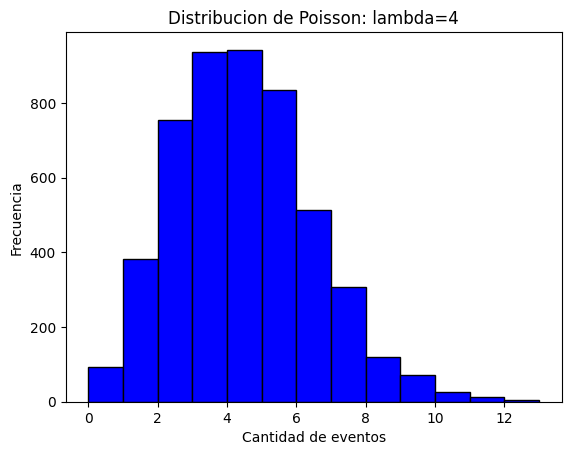

In [12]:
lambda_poi = 4          # Lambda
np.random.seed(505)     # Fijar semilla para reproducibilidad
data = np.random.poisson(lambda_poi, size=5000) # Distribucion Poisson con lambda lambda_poi
bins_no = 13            # Cantidad de barras en el histograma

# Aqui graficamos
plt.hist(data, bins=bins_no, color='blue', edgecolor='black')
plt.title(f"Distribucion de Poisson: lambda={lambda_poi}")
plt.xlabel("Cantidad de eventos")
plt.ylabel("Frecuencia")
plt.show()

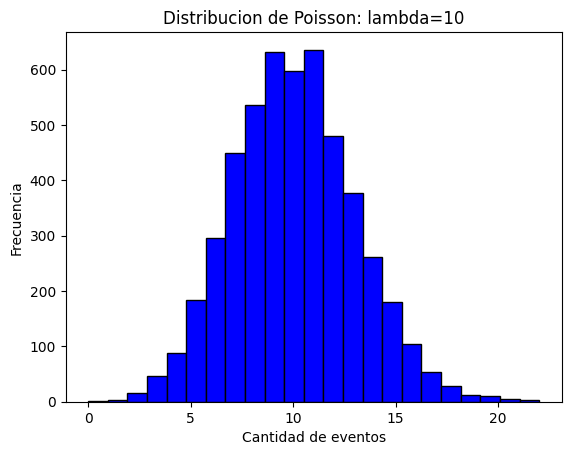

In [13]:
lambda_poi = 10         # Lambda
np.random.seed(606)     # Fijar semilla para reproducibilidad
data = np.random.poisson(lambda_poi, size=5000) # Distribucion Poisson con lambda lambda_poi
bins_no = 23            # Cantidad de barras en el histograma

# Aqui graficamos
plt.hist(data, bins=bins_no, color='blue', edgecolor='black')
plt.title(f"Distribucion de Poisson: lambda={lambda_poi}")
plt.xlabel("Cantidad de eventos")
plt.ylabel("Frecuencia")
plt.show()

#### Distribución de Bernoulli

La distribución de Bernoulli, o distribución binomial, está definida por:

$f(x) = \binom{n}{x} p^x (1-p)^{n-x}$

Los parámetros de los que depende son los siguientes:
* $n$: La cantidad de ensayos a realizar. Por ejemplo, al lanzar una moneda, hace referencia a cuántas veces se lanzará la moneda.
* $p$: La probabilidad de que éxito en un ensayo.

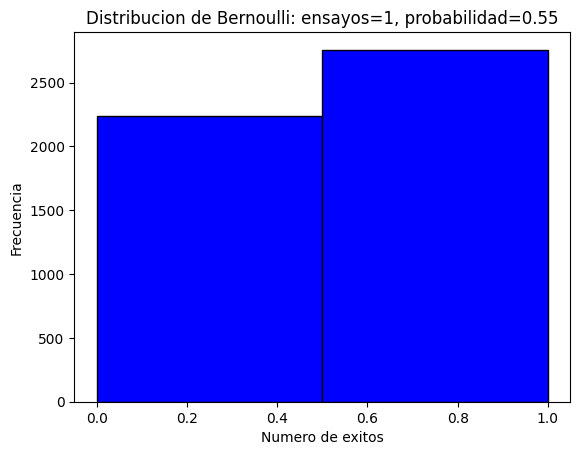

In [14]:
n = 1                   # Cantidad de ensayos
p = 0.55                # Probabilidad de exito
np.random.seed(707)     # Fijar semilla para reproducibilidad
data = np.random.binomial(n, p, size=5000) # Distribucion de Bernoulli con probabilidad p y n ensayos
bins_no = n+1           # Cantidad de barras en el histograma

# Aqui graficamos
plt.hist(data, bins=bins_no, color='blue', edgecolor='black')
plt.title(f"Distribucion de Bernoulli: ensayos={n}, probabilidad={p}")
plt.xlabel("Numero de exitos")
plt.ylabel("Frecuencia")
plt.show()

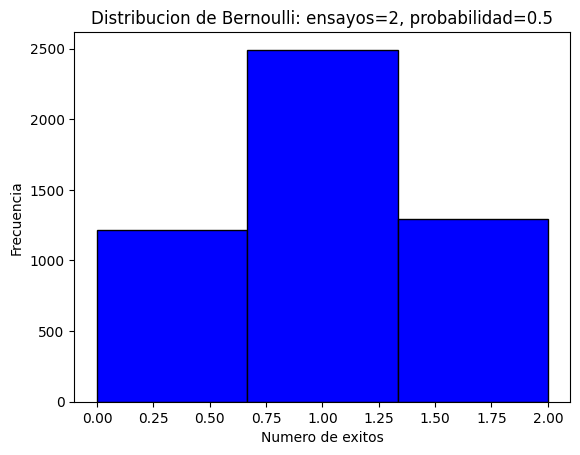

In [15]:
n = 2                   # Cantidad de ensayos
p = 0.5                 # Probabilidad de exito
np.random.seed(808)     # Fijar semilla para reproducibilidad
data = np.random.binomial(n, p, size=5000) # Distribucion de Bernoulli con probabilidad p y n ensayos
bins_no = n+1           # Cantidad de barras en el histograma

# Aqui graficamos
plt.hist(data, bins=bins_no, color='blue', edgecolor='black')
plt.title(f"Distribucion de Bernoulli: ensayos={n}, probabilidad={p}")
plt.xlabel("Numero de exitos")
plt.ylabel("Frecuencia")
plt.show()

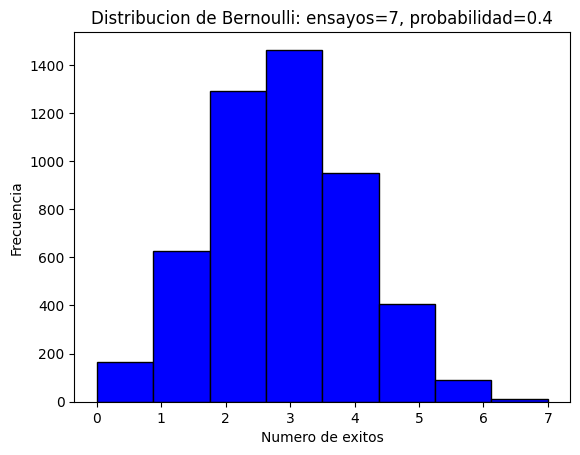

In [16]:
n = 7                   # Cantidad de ensayos
p = 0.4                 # Probabilidad de exito
np.random.seed(909)     # Fijar semilla para reproducibilidad
data = np.random.binomial(n, p, size=5000) # Distribucion de Bernoulli con probabilidad p y n ensayos
bins_no = n+1           # Cantidad de barras en el histograma

# Aqui graficamos
plt.hist(data, bins=bins_no, color='blue', edgecolor='black')
plt.title(f"Distribucion de Bernoulli: ensayos={n}, probabilidad={p}")
plt.xlabel("Numero de exitos")
plt.ylabel("Frecuencia")
plt.show()

### 0.3. Crear, guardar y cargar datos
*Ejercicio:* 
- Crear, guardar y cargar dichos datos
- Asegúrese que los datos coinciden con lo que espera
- Siga los "leads" en el código siguiente

In [17]:
# Aqui simulamos los datos, por ejemplo gaussianos
np.random.seed(101)
data = np.random.normal(0, 1, size=10)

# Aqui creamos un pandas data frame para guardar los datos
df = pd.DataFrame({
        'data': data,
    })

# Guardamos los datos en un archivo CSV
nombre_archivo = "datos_gaussianos.csv"
df.to_csv(nombre_archivo, index=False)
print(f"Datos guardados en {nombre_archivo}")

# ahora cargamos los datos
datos_cargados = pd.read_csv("datos_gaussianos.csv")

Datos guardados en datos_gaussianos.csv


### Ahora grafiquemos los datos
Compruebe que los datos están de acuerdo con lo que esperabamos. Para lo anterior, calculemos la media y la desviación estándar usando funciones de numpy y a mano. Compare sus respuestas.



La media es de 0.3558419830943586
La desviacion estandar es de 1.2367848721770833


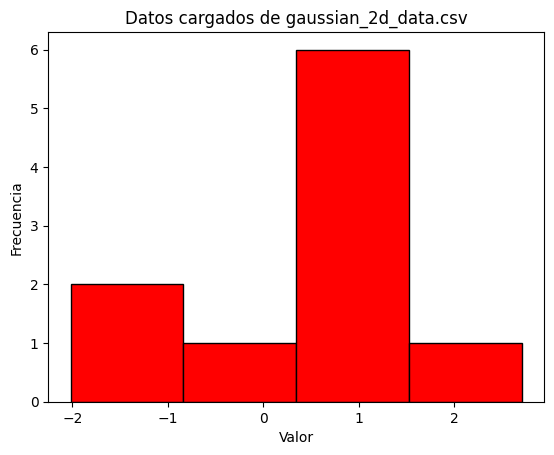

In [27]:
# Verificar media y desviacion estandar
miu = np.mean(datos_cargados)
print(f"La media es de {miu}")

stdv = np.std(datos_cargados, axis=0, ddof=1)
print(f"La desviacion estandar es de {stdv.iloc[0]}")

# Grafica
plt.hist(datos_cargados, 4, color='red', edgecolor='black')
plt.title(f"Datos cargados de {nombre_archivo}")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.show()

##### Cálculo a mano
![Imagen de WhatsApp 2025-08-15 a las 19.58.54_5786968f.jpg](<attachment:Imagen de WhatsApp 2025-08-15 a las 19.58.54_5786968f.jpg>)
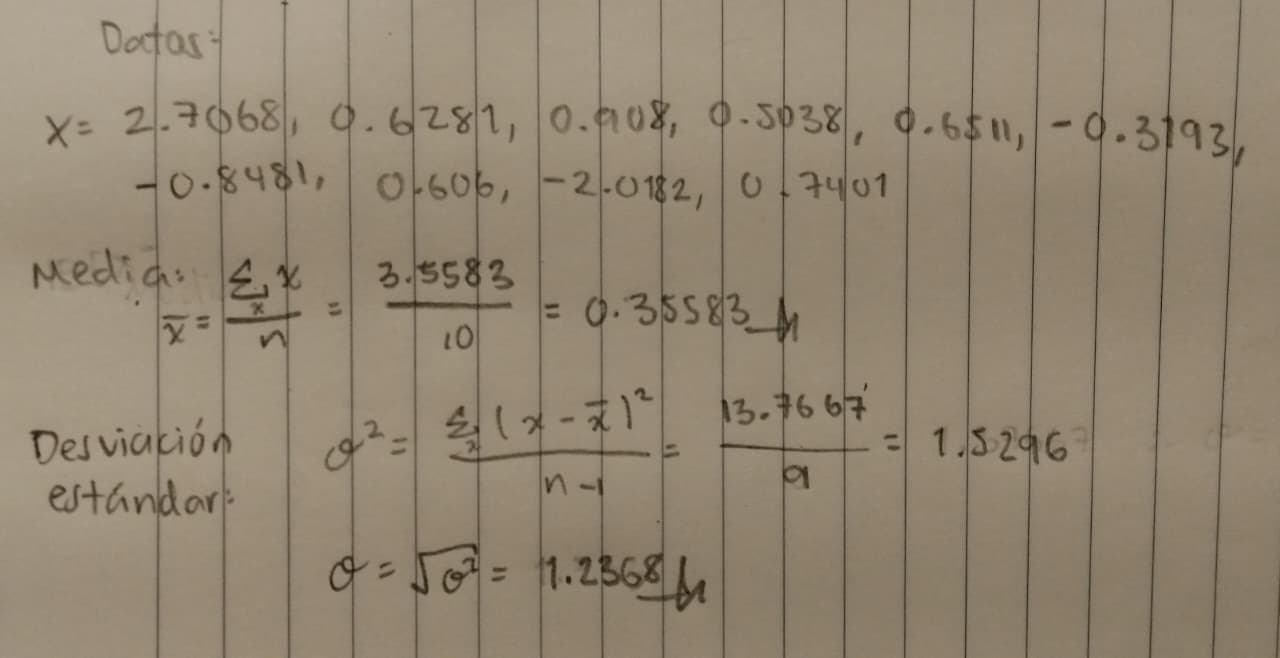

La media calculada por numpy fue de aproximadamente $0.35584$, mientras que la media que calculé a mano fue de $0.35583$, valores muy cercanos entre sí, con un error por falta de mayor precisión en los cálculos que realicé. Asimismo, la media de la distribución es de $0$, la cual podría verse muy lejana a la media muestral, pero el tamaño de la muestra tendría que ser más grande para converger al valor real.

Análogamente, la desviación estándar muestral calculada fue de aproximadamente $1.2368$ tanto en numpy como en los cálculos manuales, lo cual coincide entre sí, y se va acercando a la desviación estándar de la distribución, la cual era de $1$.

### 0.4 Probabilidad (densidad) multivariada
- Genere datos en dos dimensiones distribuidos siguiendo una probabilidad Gaussiana
- Grafique los datos usando un histograma en dos dimensiones
- Guarde los datos en un archivo csv
- Cargue los datos y grafique cada una de las variables en un histograma sencillo
- Realizar un ajuste para encontrar la PDF analítica y graficar

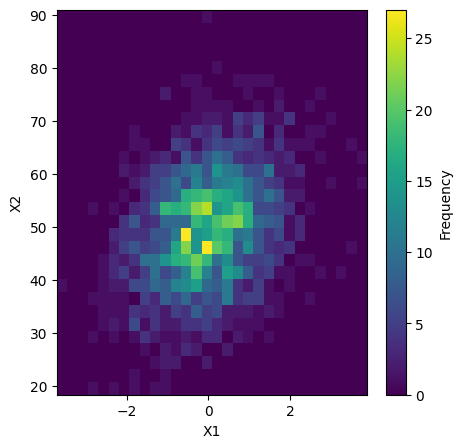

In [19]:
# Generar los datos de la distribucion normal multivariada
# [Sugerencia: use np.random.multivariate_normal()]
miu = [0, 50]           # Media de las distribuciones
cov = [[1,3], [3,100]]  # Matriz de covarianzas
np.random.seed(3)       # Establecer semilla para reproducibilidad
data = np.random.multivariate_normal(miu, cov, 2000)

# Graficar datos en histograma en dos dimensiones
plt.figure(figsize=(5, 5))
plt.hist2d(data[:,0], data[:,1], bins=30, cmap='viridis')
plt.colorbar(label='Frequency')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

# Guardar datos en csv
df = pd.DataFrame(data, columns=['X1', 'X2'])
nombre_archivo = 'gaussian_2d_data.csv'
df.to_csv(nombre_archivo, index=False)

# Cargar datos
df_cargado = pd.read_csv(nombre_archivo)


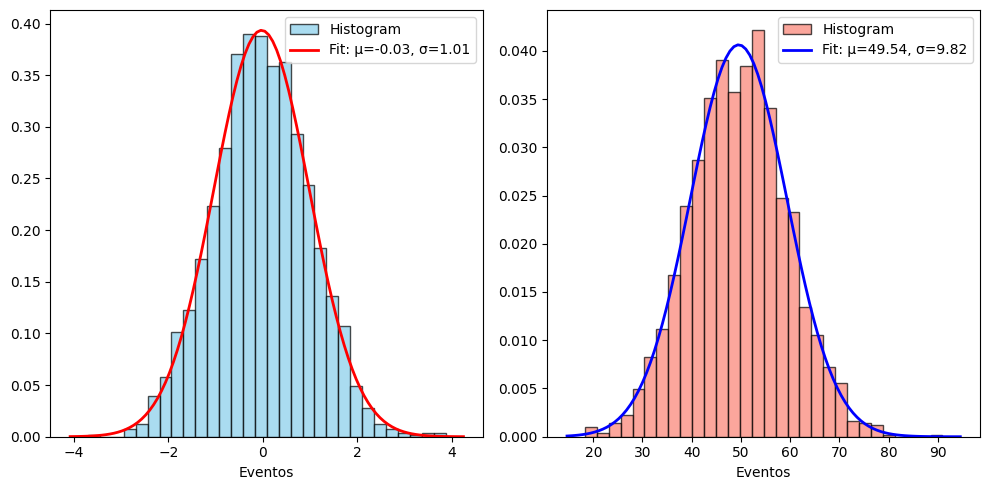

In [20]:
# Tamaño de la figura
plt.figure(figsize=(10, 5))

# First variable histogram and fit
plt.subplot(1, 2, 1)
x1 = df_cargado['X1']
mu, std = norm.fit(x1) # Hacer el fit
plt.hist(x1, bins=30, density=True, color='skyblue', edgecolor='black', alpha=0.7, 
         label='Histogram')

# graficar el ajuste
xmin, xmax = plt.xlim()
x_fit = np.linspace(xmin, xmax, 100)
y_fit = norm.pdf(x_fit, mu, std)
plt.plot(x_fit, y_fit, 'r-', linewidth=2, label=f'Fit: μ={mu:.2f}, σ={std:.2f}')
plt.xlabel('Eventos')
plt.legend()

# x2
plt.subplot(1, 2, 2)
x2 = df_cargado['X2']
mu, std = norm.fit(x2)
plt.hist(x2, bins=30, density=True, color='salmon', edgecolor='black', alpha=0.7, 
         label='Histogram')

# graficar el ajuste 
ymin, ymax = plt.xlim()
y_fit = np.linspace(ymin, ymax, 100)
y_pdf = norm.pdf(y_fit, mu, std)
plt.plot(y_fit, y_pdf, 'b-', linewidth=2, label=f'Fit: μ={mu:.2f}, σ={std:.2f}')
plt.xlabel('Eventos')
plt.legend()

plt.tight_layout()
plt.show()

## 1. Teorema del límite central

### 1.1 Distribuciones Gaussianas
**Ejercicio:** Muestre numéricamente que la combinación lineal de distribuciones Gaussianas es una distribución Gaussiana. Asegúrese de que esta nueva distribución en efecto sea Gaussiana con una prueba de Shapiro-Wilk, es decir encuentre un p-valor a aceptar que es Gaussiana.


In [ ]:

def sum_gaussians_tlc(num_samples=10000, n_gaussians=3):
    # Generate independent Gaussian distributions
    np.random.seed(5)                                           # Fijar semilla para reproducibilidad
    means = np.random.randint(-100, 100, size=n_gaussians)      # Las medias se encontrarán entre -100 y 100
    std_devs = np.random.randint(1, 5, size=n_gaussians)        # Las desviaciones estandar serán valores entre 1 y 5
    coefficients = np.random.random(n_gaussians)                # Los coeficientes para la combinación lineal estarán entre 0 y 1

    # Initialize an empty list to store the samples
    gaussians = []

    # Loop through each Gaussian distribution
    for i in range(n_gaussians):
        # Generate samples for the current Gaussian distribution
        samples = np.random.normal(means[i], std_devs[i], num_samples)
        # Add the generated samples to the list
        gaussians.append(samples)

    # Linear combination of these Gaussians
    linear_combination = np.zeros(num_samples)
    for i in range(n_gaussians):
        linear_combination += coefficients[i] * gaussians[i] # Calculo de la combinacion lineal

    # Fit a Gaussian (normal) distribution to the linear combination
    mu, std = norm.fit(linear_combination)

    # Plot the histogram of the linear combination
    plt.figure(figsize=(8, 6))
    count, bins, _ = plt.hist(linear_combination, bins=50, density=True, alpha=0.7, color='blue', edgecolor='black', label='Linear Combination')

    # Plot the Gaussian fit
    xmin, xmax = plt.xlim()  # Get the limits of the x-axis for plotting the fit over the same range
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std) # Gaussian distribution fit

    # Scale the fit by the max height of the histogram to make it align
    plt.plot(x, p, 'k', linewidth=2, label=f'Gaussian mean={mu:.2f}, std={std:.2f}')

    # Perform the Shapiro-Wilk test for normality
    stat, p_value = shapiro(linear_combination)

    # Display the p-value on the plot
    plt.text(xmin + (xmax - xmin) * 0.05, max(count) * 0.9, f'p-value: {p_value:.5f}', fontsize=12, color='red')

    # Add labels, title, and legend
    plt.title(f'Linear Combination of {n_gaussians} Gaussian Distributions\nSample Size: {num_samples}')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()

    # Show the plot
    plt.show()

    # Print the p-value
    if p_value > 0.05:
        print(f"Con 95% de confianza y un p-valor de {p_value}, no se puede descartar que la distribucion sea normal.")
    else:
        print(f"Con 95% de confianza y un p-valor de {p_value}, se descarta que los datos provengan de una distribucion normal.")


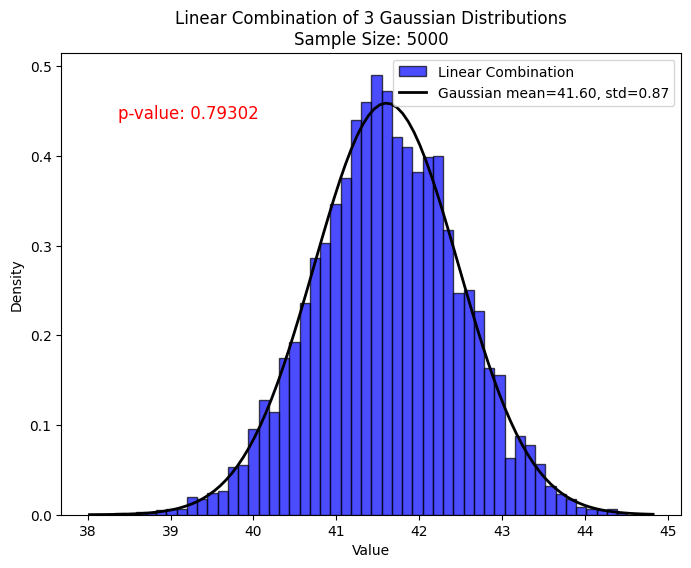

Con 95% de confianza y un p-valor de 0.793015001800474, no se puede descartar que la distribucion sea normal.


In [24]:
sum_gaussians_tlc(num_samples=5000)

### 1.2 Distribuciones uniformes

**Ejercicio**: Repita el ejercicio anterior con distribuciones uniformes finitas. Es decir, el teorema establece que la distribución de
la combinación lineal de un gran número de variables aleatorias independientes e idénticamente distribuidas se aproximará a una distribución normal. Sume cuando menos 50 distribuciones.

In [25]:
def sum_uniforms_tlc(num_samples=1000000, n_uniforms=100):
    # Generate independent uniform distributions
    lower_bounds = np.random.randint(1,100,size=n_uniforms)         # El limite inferior estara entre 1 y 100
    upper_bounds = np.random.randint(1000, 2000, size=n_uniforms)   # El limite superior estara entre 1000 y 2000 (siempre mayor al limite inferior)
    coefficients = np.random.random(n_uniforms)                     # Los coeficientes de la combinacion lineal estaran entre 0 y 1

    uniforms = []

    # Loop through each uniform distribution
    for i in range(n_uniforms):
        # Generate random samples for the current uniform distribution
        current_samples = np.random.random_sample(size=num_samples) * (upper_bounds[i] - lower_bounds[i]) + lower_bounds[i]
        # Append the generated samples to the list
        uniforms.append(current_samples)
    
    # Linear combination of these uniforms
    linear_combination = np.zeros(num_samples)
    for i in range(n_uniforms):
        linear_combination += coefficients[i] * uniforms[i] # Combinacion lineal

    # Fit a Gaussian (normal) distribution to the linear combination
    mu, std = norm.fit(linear_combination)

    # Plot the histogram of the linear combination
    plt.figure(figsize=(8, 6))
    count, bins, _ = plt.hist(linear_combination, bins=50, density=True, alpha=0.7, color='blue', edgecolor='black', label='Linear Combination')

    # Plot the Gaussian fit
    xmin, xmax = plt.xlim()  # Get the limits of the x-axis for plotting the fit over the same range
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std) # Ajuste de la PDF

    # Scale the fit by the max height of the histogram to make it align
    plt.plot(x, p, 'k', linewidth=2, label=f'Gaussian mu={mu:.2f}, sigma={std:.2f}')

    # Perform the Shapiro-Wilk test for normality
    stat, p_value = shapiro(linear_combination)

    # Display the p-value on the plot
    plt.text(xmin + (xmax - xmin) * 0.05, max(count) * 0.9, f'p-value: {p_value:.5f}', fontsize=12, color='red')

    # Add labels, title, and legend
    plt.title(f'Linear Combination of {n_uniforms} Uniform Distributions\nSample Size: {num_samples}')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()

    # Show the plot
    plt.show()

    # Print the p-value
    if p_value > 0.05:
        print(f"Con 95% de confianza y un p-valor de {p_value}, no se puede descartar que la distribucion sea normal.")
    else:
        print(f"Con 95% de confianza y un p-valor de {p_value}, se descarta que los datos provengan de una distribucion normal.")


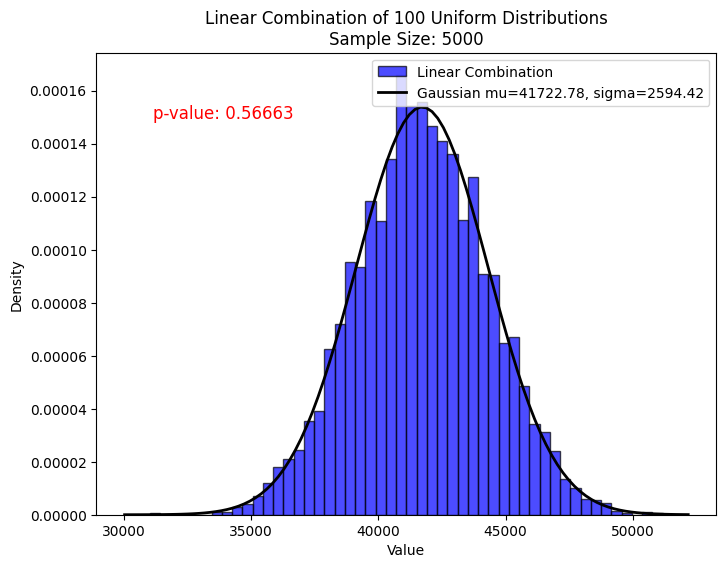

Con 95% de confianza y un p-valor de 0.5666318168019012, no se puede descartar que la distribucion sea normal.


In [26]:
sum_uniforms_tlc(num_samples = 5000)